In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.ndimage import gaussian_filter
from skimage import data

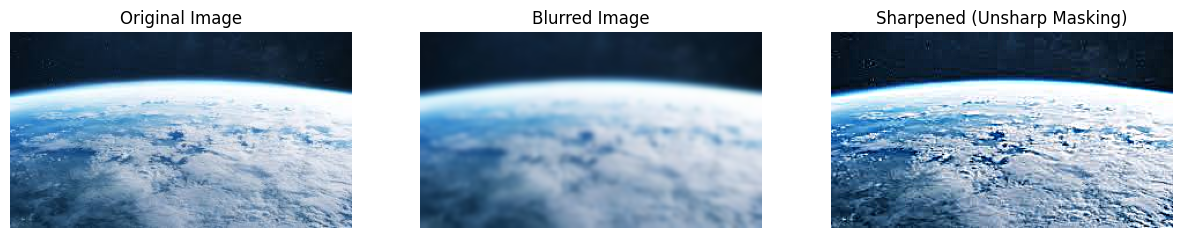

In [2]:
image = cv2.imread('space.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 

sigma=2
amount=1.5

image_float = image.astype(np.float32) / 255.0

blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(blurred)
ax[1].set_title("Blurred Image")
ax[1].axis("off")
ax[2].imshow(sharpened)
ax[2].set_title("Sharpened (Unsharp Masking)")
ax[2].axis("off")
plt.show()

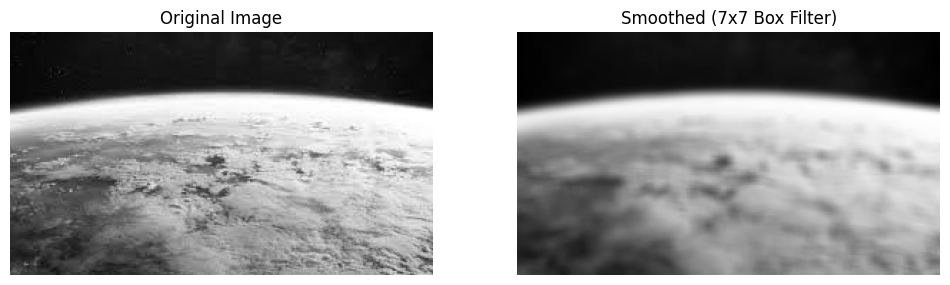

In [3]:
#task 1
img = cv2.imread("space.jpg",0)

kernel = np.ones((7,7)) / 49
smoothed = ndimage.convolve(img, kernel)


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(smoothed, cmap='gray')
plt.title("Smoothed (7x7 Box Filter)")
plt.axis("off")

plt.show()

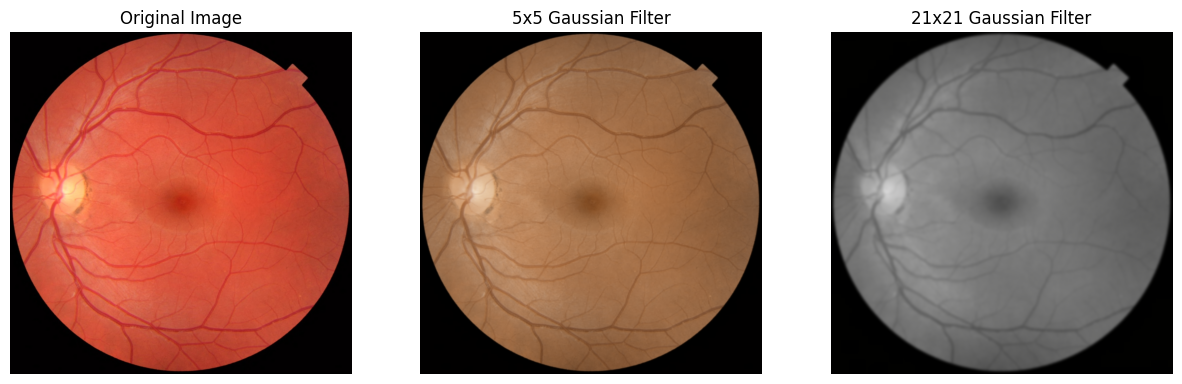

In [8]:
# task 2
image = data.retina()   

gaussian_5 = gaussian_filter(image, sigma=1)
gaussian_21 = gaussian_filter(image, sigma=5)


plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gaussian_5, cmap='gray')
plt.title("5x5 Gaussian Filter")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(gaussian_21, cmap='gray')
plt.title("21x21 Gaussian Filter")
plt.axis("off")

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.847059..0.86274505].


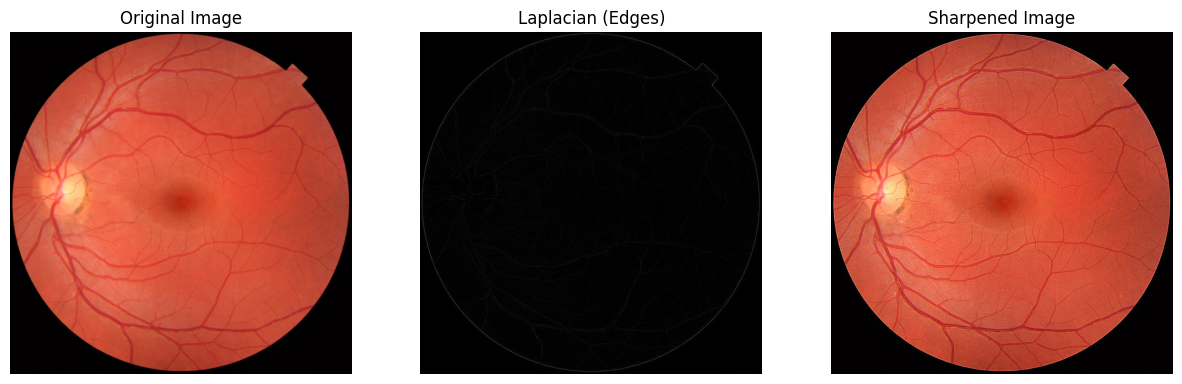

In [9]:
#task 3

image = data.retina()   
image_float = image.astype(np.float32) / 255.0

laplacian = cv2.Laplacian(image_float, cv2.CV_32F, ksize=3)

sharpened = np.clip(image_float - laplacian, 0, 1)


plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(image_float, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(laplacian, cmap='gray')
plt.title("Laplacian (Edges)")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened Image")
plt.axis("off")
plt.show()